In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Варіант 5 — Дніпро
lam = 0.18
true_mean = 1 / lam

rng = np.random.default_rng(5)

print("Варіант 5 — Дніпро")
print("λ =", lam)
print("Теоретичне середнє E[X] =", true_mean, "хв")

Варіант 5 — Дніпро
λ = 0.18
Теоретичне середнє E[X] = 5.555555555555555 хв


In [2]:
for n in [5, 50, 500, 20000]:
    sample = rng.exponential(
        scale=1 / lam,
        size=n
    )

    sample_mean = sample.mean()
    difference = abs(sample_mean - true_mean)

    print(
        f"n = {n:5d} | "
        f"середнє = {sample_mean:.4f} | "
        f"різниця = {difference:.4f}"
    )

n =     5 | середнє = 5.1087 | різниця = 0.4469
n =    50 | середнє = 4.6249 | різниця = 0.9306
n =   500 | середнє = 5.2392 | різниця = 0.3163
n = 20000 | середнє = 5.5201 | різниця = 0.0355


Теоретичне середнє для Дніпра становить приблизно 5.56 хв.

Зі збільшенням розміру вибірки вибіркове середнє загалом
наближається до теоретичного значення.

Для окремих невеликих вибірок різниця може випадково
збільшуватися. Наприклад, при n=50 вона виявилась більшою,
ніж при n=5.

Однак при n=20000 різниця становить лише близько 0.04 хв.
Це демонструє закон великих чисел: при великих n вибіркове
середнє наближається до математичного сподівання.

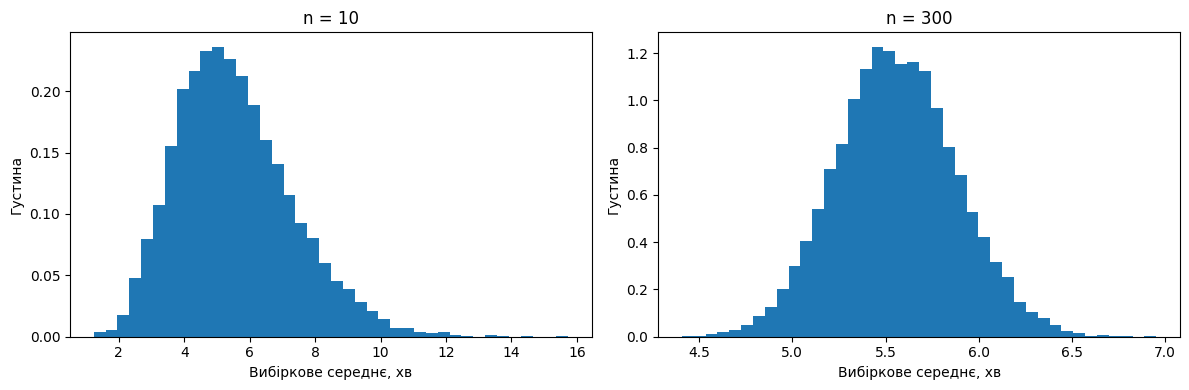

In [3]:
n_repeats = 10000

means_n10 = rng.exponential(
    scale=1 / lam,
    size=(n_repeats, 10)
).mean(axis=1)

means_n300 = rng.exponential(
    scale=1 / lam,
    size=(n_repeats, 300)
).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(means_n10, bins=40, density=True)
axes[0].set_title("n = 10")
axes[0].set_xlabel("Вибіркове середнє, хв")
axes[0].set_ylabel("Густина")

axes[1].hist(means_n300, bins=40, density=True)
axes[1].set_title("n = 300")
axes[1].set_xlabel("Вибіркове середнє, хв")
axes[1].set_ylabel("Густина")

plt.tight_layout()
plt.show()

При n=10 розподіл вибіркових середніх ще має помітну
асиметрію, що пов'язано зі сильно скошеним вихідним
експоненційним розподілом.

При n=300 гістограма стає значно більш симетричною
і набуває дзвоноподібної форми.

Крім того, при n=300 значення вибіркових середніх
зосереджені ближче до теоретичного середнього 5.56 хв.

Це демонструє центральну граничну теорему: зі збільшенням
n вибірковий розподіл середнього наближається до нормального,
навіть якщо вихідний розподіл не є нормальним.

In [4]:
results = []

for n in [10, 30, 100, 300]:

    # Теоретична стандартна похибка
    se_theoretical = true_mean / np.sqrt(n)

    # 10000 повторних вибірок
    sample_means = rng.exponential(
        scale=1 / lam,
        size=(10000, n)
    ).mean(axis=1)

    # Стандартне відхилення вибіркових середніх
    se_simulation = sample_means.std()

    results.append({
        "n": n,
        "Теоретична SE": se_theoretical,
        "SE за симуляцією": se_simulation
    })

se_table = pd.DataFrame(results)

se_table

,n,Теоретична SE,SE за симуляцією
0,10,1.756821,1.778820
1,30,1.014301,1.019810
2,100,0.555556,0.551524
3,300,0.320750,0.320976


Теоретична стандартна похибка та стандартне відхилення,
отримане за допомогою симуляції, мають близькі значення.

Зі збільшенням n стандартна похибка зменшується:

n=10   → SE ≈ 1.76
n=30   → SE ≈ 1.01
n=100  → SE ≈ 0.56
n=300  → SE ≈ 0.32

Отже, чим більший розмір вибірки, тим менший розкид
вибіркових середніх навколо теоретичного середнього.

Симуляція добре узгоджується з теоретичною формулою
SE = σ / √n.

In [5]:
se_25 = true_mean / np.sqrt(25)
se_100 = true_mean / np.sqrt(100)

print("SE при n=25:", se_25)
print("SE при n=100:", se_100)
print("Співвідношення:", se_25 / se_100)

SE при n=25: 1.1111111111111112
SE при n=100: 0.5555555555555556
Співвідношення: 2.0


При n=25 стандартна похибка становить приблизно 1.11 хв,
а при n=100 — приблизно 0.56 хв.

Розмір вибірки збільшився у 4 рази, але стандартна
похибка зменшилася лише у 2 рази.

Причина полягає у формулі:

SE = σ / √n

Стандартна похибка залежить не безпосередньо від n,
а від квадратного кореня з n.

√4 = 2, тому збільшення вибірки у 4 рази зменшує
стандартну похибку лише у 2 рази.

Це демонструє закон убуваючої віддачі: для подальшого
зменшення похибки потрібно збирати дедалі більше даних.

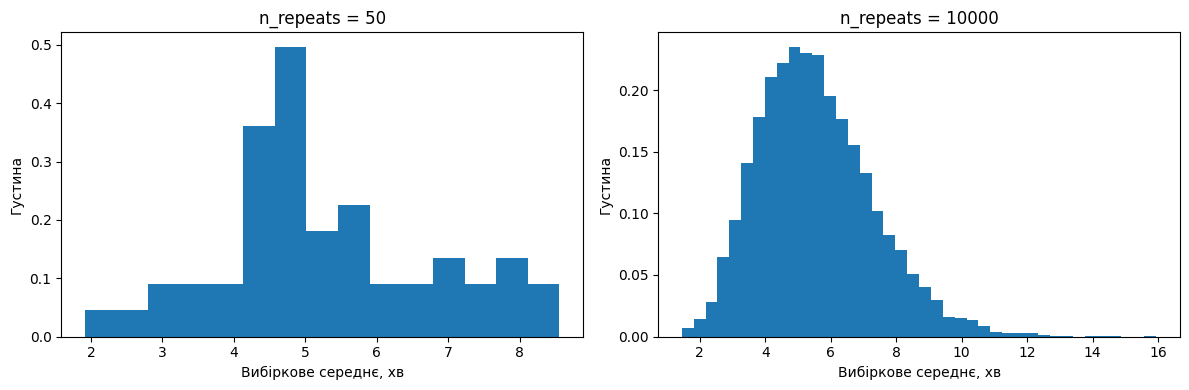

In [6]:
means_50 = rng.exponential(
    scale=1 / lam,
    size=(50, 10)
).mean(axis=1)

means_10000 = rng.exponential(
    scale=1 / lam,
    size=(10000, 10)
).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(means_50, bins=15, density=True)
axes[0].set_title("n_repeats = 50")
axes[0].set_xlabel("Вибіркове середнє, хв")
axes[0].set_ylabel("Густина")

axes[1].hist(means_10000, bins=40, density=True)
axes[1].set_title("n_repeats = 10000")
axes[1].set_xlabel("Вибіркове середнє, хв")
axes[1].set_ylabel("Густина")

plt.tight_layout()
plt.show()

При n_repeats=50 гістограма має нерівну та нестабільну форму,
оскільки для побудови вибіркового розподілу використано
лише 50 вибіркових середніх.

При n_repeats=10000 гістограма значно гладша і краще
відображає справжню форму вибіркового розподілу.

n визначає кількість спостережень усередині однієї вибірки
і впливає на розкид та форму розподілу вибіркового середнього.

n_repeats визначає кількість повторних вибірок і тому
впливає на те, наскільки точно та гладко гістограма
відображає цей розподіл.

Контрольні питання

1. Чим відрізняються закон великих чисел і центральна
гранична теорема?

Закон великих чисел відповідає на питання, куди прямує
вибіркове середнє при збільшенні розміру вибірки.
Зі збільшенням n воно наближається до математичного
сподівання генеральної сукупності.

Центральна гранична теорема описує форму та розкид
вибіркового розподілу середнього. При достатньо великому n
цей розподіл наближається до нормального, навіть якщо
вихідна генеральна сукупність не є нормальною.


2. Чому використано сильно скошений експоненційний розподіл?

Експоненційний розподіл сильно скошений і не має
дзвоноподібної форми.

Завдяки цьому можна наочно побачити дію центральної
граничної теореми: хоча початкові дані не є нормально
розподіленими, розподіл вибіркових середніх при великому n
стає приблизно нормальним.

Якби вихідні дані вже мали нормальний розподіл, цей ефект
було б значно складніше продемонструвати наочно.


3. Чому стандартна похибка зменшується пропорційно √n,
а не n?

Стандартна похибка середнього визначається формулою:

SE = σ / √n.

Тому для зменшення стандартної похибки у 2 рази потрібно
збільшити кількість спостережень не у 2, а у 4 рази.

Наприклад, перехід від n=25 до n=100 збільшує вибірку
у 4 рази, але зменшує стандартну похибку лише у 2 рази.

Практично це означає, що отримання дедалі точніших оцінок
вимагає значного збільшення обсягу даних.